## Codigo para pruebas de autoencoder que recrea posiciones

In [25]:
import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  
import chess
import chess.pgn
import joblib

# Imports de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Para cuando usas múltiples GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.ion()

In [26]:
# Verificación de aceleración por GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo activo: cuda
GPU detectada: NVIDIA GeForce RTX 4060 Laptop GPU


In [27]:
ELO_MIN = 1000 
ELO_MAX = 3322
ELO_MEAN = 1851.1
ELO_STD = 495.3  
ELO_MEDIAN = 1839.0
ELO_Q1 = 1442.0
ELO_Q3 = 2230.0
ELO_IQR = ELO_Q3 - ELO_Q1

In [28]:
class ChessDataset(Dataset):
    def __init__(self, npz_path, plies_a_usar=None, flatten=True, norm_type="standard"):
        datos = np.load(npz_path)

        X_completo = datos['X']
        plies_guardados = datos['plies_guardados'].tolist()
        
        if plies_a_usar is None:
            indices = list(range(len(plies_guardados)))
        else:
            indices = [plies_guardados.index(p) for p in plies_a_usar]
            
        X_filtrado = X_completo[:, indices, :]
        
        if flatten:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0], -1)
            
        self.X = torch.tensor(X_filtrado, dtype=torch.float32)
        
        if norm_type == "minmax":
            y_seleccionada = datos['y_minmax']
        elif norm_type == "robust":
            y_seleccionada = datos['y_robust']
        elif norm_type == "raw":
            y_seleccionada = datos['y_raw']
        else:
            y_seleccionada = datos['y_standard'] # Por defecto
            
        # Lo pasamos a tensor y le damos forma (N, 1)
        self.y = torch.tensor(y_seleccionada, dtype=torch.float32).view(-1, 1)
        
        self.input_dim = self.X.shape[1] if flatten else self.X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [48]:
plies = [21]
ply = plies
flatten = 1
norm = "raw" # "standard", "minmax", "robust", "raw"
crit = "mse" # "huber", "mse"
print("Cargando datasets a la memoria...")

train_ds = ChessDataset("../data/generado/only_enc/train.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
val_ds = ChessDataset("../data/generado/only_enc/val.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
test_ds = ChessDataset("../data/generado/only_enc/test.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)

# El DataLoader se encarga de crear los batches y hacer el shuffle usando C++ internamente
#train = np.load("../data/movimientos_13.npy").astype("float32")[:,2,:]
#train_ds = torch.tensor(train, dtype=torch.float32)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

Cargando datasets a la memoria...


In [49]:
encoder_salida = f"../data/encoders/only_enc/prueba.pth"
#encoder_salida = f"../data/encoders/only_enc/pesos_norm_{norm}_ply_{ply}_loss_{crit}.pth"
pred_salida = f"../data/predict/prueba.npy"
#pred_salida = f"../data/predict/norm_{norm}_ply_{ply}_loss_{crit}.npy"

In [50]:
# Encoder para una posición

class ChessEncoder(nn.Module):
    def __init__(self):
        super(ChessEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(832, 500),
            nn.ReLU(),
            nn.Linear(500, 300),
            nn.ReLU(),
            nn.Linear(300, 180),
            nn.ReLU(),
            nn.Linear(180, 108),
            nn.ReLU(),
            nn.Linear(108, 65) 
        )
        self.decoder = nn.Sequential(
                nn.Linear(65, 108), 
                nn.ReLU(),
                nn.Linear(108, 180),
                nn.ReLU(),
                nn.Linear(180, 300),
                nn.ReLU(),
                nn.Linear(300, 500),
                nn.ReLU(),
                nn.Linear(500, 832),
                nn.Sigmoid()
            )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [51]:
modelo = ChessEncoder().to(device)

optimizador = torch.optim.Adam(modelo.parameters(), lr=3e-2)
criterio = nn.BCELoss()
criterio_individual = nn.BCELoss(reduction='none')

In [52]:
# --- BUCLE DE ENTRENAMIENTO ---
epocas = 50
paciencia = 5
mejor_val_loss = float('inf')
epocas_sin_mejora = 0

for epoca in range(epocas):
    modelo.train()
    train_loss = 0.0
    
    for batch_X, _ in train_loader:

        batch_X = batch_X.to(device)
        reconstruccion = modelo(batch_X)
        loss = criterio(reconstruccion, batch_X)
        optimizador.zero_grad()
        loss.backward()
        optimizador.step()
        
        train_loss += loss.item() * batch_X.size(0)
        
    modelo.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            reconstruccion = modelo(batch_X)
            loss = criterio(reconstruccion, batch_X)
            val_loss += loss.item() * batch_X.size(0)
            
    # Promedios de la época
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    print(f"Época {epoca+1}/{epocas} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # --- EARLY STOPPING ---
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epocas_sin_mejora = 0
        
        # 1. Empaquetamos los pesos y los metadatos del experimento
        checkpoint = {
            'arquitectura': 'Dense_512_256_128_32',
            'epoca_optima': epoca + 1,
            'estado_pesos': modelo.state_dict()
        }
        
        # 2. Guardo el archivo
        torch.save(checkpoint, encoder_salida) 
        
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= paciencia:
            print(f"\nEarly stopping activado. El modelo no mejoró en {paciencia} épocas.")
            print(f"Recuperando los mejores pesos de la época {epoca + 1 - paciencia}...")
            
            # 3. Cargamos el archivo completo a la RAM
            checkpoint_recuperado = torch.load(encoder_salida)
            
            modelo.load_state_dict(checkpoint_recuperado['estado_pesos'])

            break

Época 1/50 | Train Loss: 4.8546 | Val Loss: 4.8933
Época 2/50 | Train Loss: 4.8756 | Val Loss: 4.8933
Época 3/50 | Train Loss: 4.8756 | Val Loss: 4.8933
Época 4/50 | Train Loss: 4.8756 | Val Loss: 4.8933
Época 5/50 | Train Loss: 4.8756 | Val Loss: 4.8933
Época 6/50 | Train Loss: 4.8756 | Val Loss: 4.8933

Early stopping activado. El modelo no mejoró en 5 épocas.
Recuperando los mejores pesos de la época 1...


C:\Users\agust\AppData\Local\Temp\ipykernel_12764\203858454.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_recuperado = torch.load(encoder_salida)


In [53]:
modelo.eval() # Modo evaluación
test_losses = []
test_elo = []
criterio_individual = nn.BCELoss(reduction='none')

print("Calculando predicciones en el Test set...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        # Predecir
        reconstruccion = modelo(batch_X)
        loss = criterio_individual(reconstruccion, batch_X)
        loss_por_tablero = loss.mean(dim=1) 
        test_elo.extend(batch_y.flatten())
        test_losses.extend(loss_por_tablero.cpu())

Calculando predicciones en el Test set...


In [54]:
print(np.corrcoef(test_losses, test_elo)[0, 1])

-0.09695380103474449


In [55]:
modelo.eval()

losses_val = []
elos_val = []

# Usar reduction='none' para obtener el error individual de cada tablero, no el promedio del batch


with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        
        reconstruccion = modelo(batch_X)
        # Calcula el error matriz contra matriz
        # loss_por_tablero tendrá forma (Batch_size, 832)
        loss_matriz = criterio_individual(reconstruccion, batch_X)
        
        # Promediamos los 832 bits para obtener 1 solo valor de "caos" por tablero
        loss_por_tablero = loss_matriz.mean(dim=1) 
        
        # Guardamos en listas para scikit-learn o scipy
        losses_val.extend(loss_por_tablero.cpu().numpy())
        elos_val.extend(batch_y.numpy().flatten())

# Ahora tienes los dos arrays listos para tu regresión: a * loss + b = ELO

In [14]:
losses_val = np.array(losses_val)
elos_val = np.array(elos_val)

indices = np.argsort(losses_val)
indices_filtrados = indices[:-10]

losses_val_filtrado = losses_val[indices_filtrados]
elos_val_filtrado = elos_val[indices_filtrados]

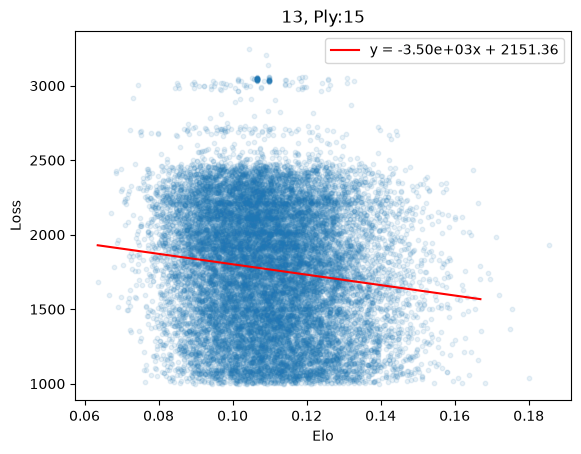

In [15]:
plt.scatter(losses_val,elos_val, alpha=0.1, s=10)
yticks = np.arange(0, 0.18, 0.02)
# Ajuste lineal: grado 1 = línea recta (y = m*x + b)
m, b = np.polyfit(losses_val_filtrado, elos_val_filtrado, deg=1)

# Genero puntos de la recta para dibujarla prolija
x_recta = np.linspace(min(losses_val_filtrado), max(losses_val_filtrado), 100)
y_recta = m * x_recta + b

plt.plot(x_recta, y_recta, color="red", label=f"y = {m:.2e}x + {b:.2f}")
plt.title(f"13, Ply:{15}")
plt.xlabel("Elo")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [22]:
from scipy.stats import linregress

# Asumiendo que losses_train y elos_train son arrays de numpy
slope, intercept, r_value, p_value, std_err = linregress(losses_val,elos_val)

print(f"La ecuación es: ELO = {slope} * loss + {intercept}")
print(f"Correlación (R): {r_value:.4}") 

La ecuación es: ELO = -4121.83740234375 * loss + 1965.6915283203125
Correlación (R): -0.1762


In [23]:
y_pred_real =  slope * np.array(test_losses) + intercept

In [24]:
errores_absolutos = np.abs(test_elo - y_pred_real)
errores_cuadraticos = (test_elo - y_pred_real) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)

print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

MAE (Error Absoluto Medio):   377.9 puntos de Elo
Mediana del Error:            354.4 puntos de Elo
RMSE (Raíz Error Cuadrático): 454.1 puntos de Elo
Peor equivocación del modelo: 1430.4 puntos de Elo


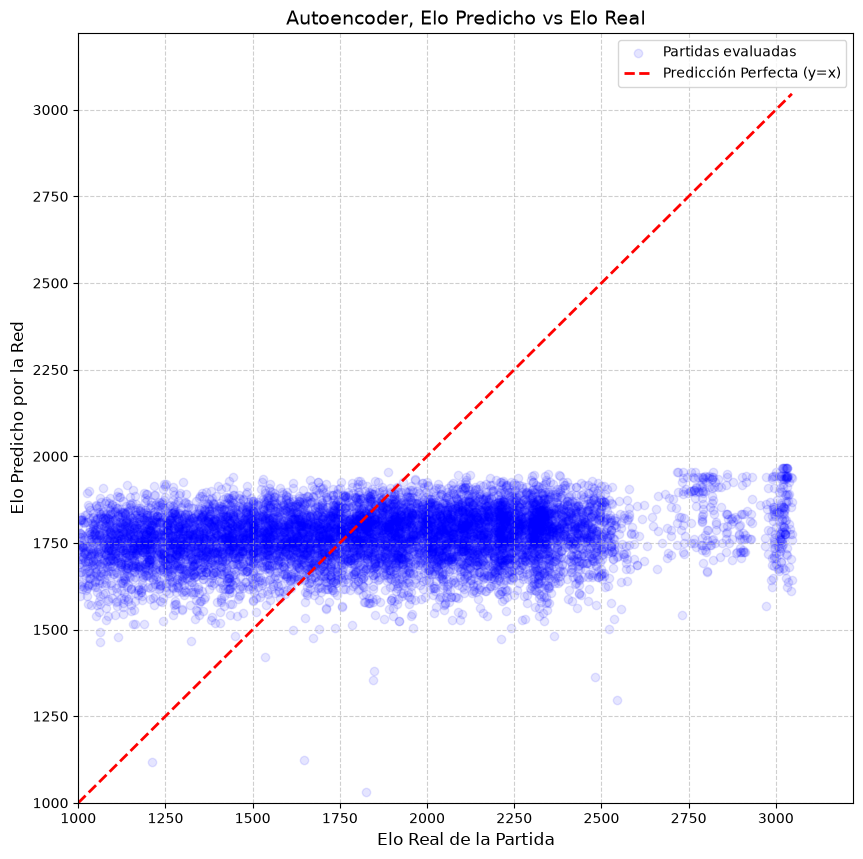

In [25]:
plt.figure(figsize=(10, 10))

plt.scatter(test_elo, y_pred_real, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(test_elo), min(y_pred_real))
max_val = max(max(test_elo), max(y_pred_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Autoencoder, Elo Predicho vs Elo Real', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()

In [20]:

errores_absolutos = np.abs(np.array(test_elo) - ELO_MEAN)
errores_cuadraticos = (np.array(test_elo) - ELO_MEAN) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)
print(f"Benchmark Trivial: Mean of Train")
print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

Benchmark Trivial: Mean of Train
MAE (Error Absoluto Medio):   241.5 puntos de Elo
Mediana del Error:            215.1 puntos de Elo
RMSE (Raíz Error Cuadrático): 295.4 puntos de Elo
Peor equivocación del modelo: 993.9 puntos de Elo


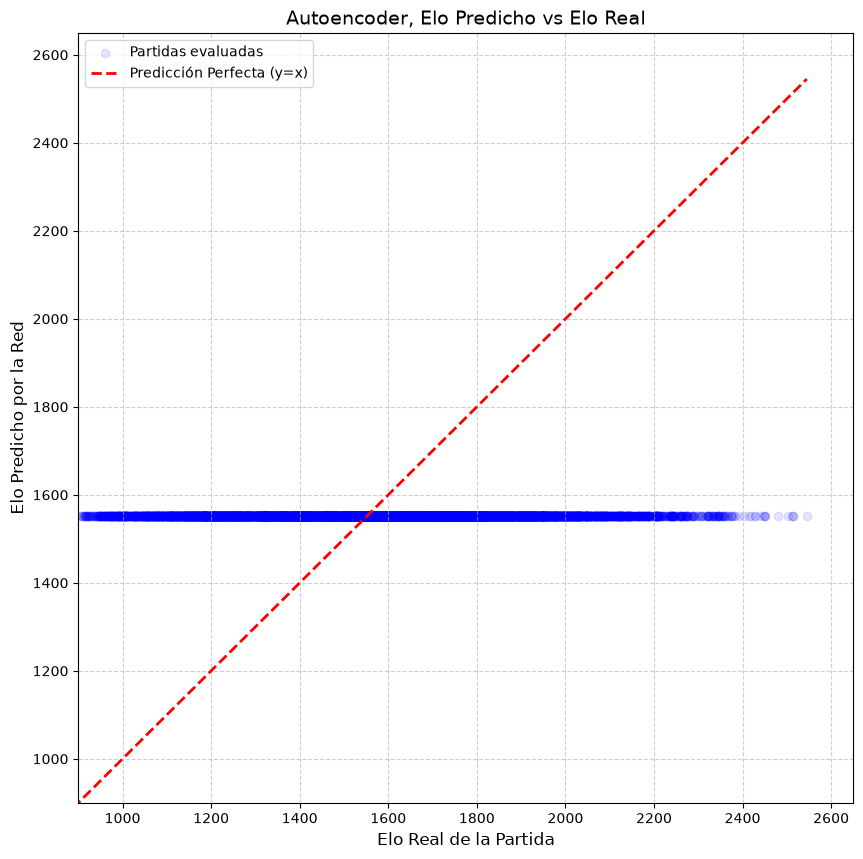

In [21]:
plt.figure(figsize=(10, 10))
promedio = [ELO_MEAN] * len(test_elo)
plt.scatter(test_elo, promedio, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(test_elo), min(y_pred_real))
max_val = max(max(test_elo), max(y_pred_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Autoencoder, Elo Predicho vs Elo Real', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()